# IMU + Action Label Validation Notebook

**Purpose**: Validate action labels by examining IMU patterns around specific labeled moments.

**Features**:
1. ✅ **100% IMU coverage** - all labeled videos have IMU on Ego4D
2. 🔍 **Moment-focused** - zoom into ±5s windows around each label
3. 📊 **Duration analysis** - see how long each action type typically lasts
4. 🎯 **Action filtering** - focus on Locomotion, Error, Search, etc.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# Paths
LABELS_PATH = '../data/labels/action_labels_llm_clean.csv'
IMU_DIR = Path('../data/ego4d_data/v2/imu')

## 1. Load Data & Check Coverage

In [13]:
# Load labels
df = pd.read_csv(LABELS_PATH)
print(f"📊 Total narrations: {len(df):,}")
print(f"📹 Unique videos: {df['video_uid'].nunique():,}")

# Check local IMU files
imu_files = list(IMU_DIR.glob('*.csv'))
imu_files = [f for f in imu_files if f.stem not in ['manifest']]
local_imu_uids = set(f.stem for f in imu_files)

labeled_uids = set(df['video_uid'].unique())
local_coverage = labeled_uids.intersection(local_imu_uids)

print(f"\n💾 Local IMU files: {len(imu_files)} ({len(local_coverage):,} of our labeled videos)")
print(f"☁️  Ego4D coverage: 100% (all {len(labeled_uids):,} videos have IMU available)")
print(f"\n✅ Ready to download remaining {len(labeled_uids) - len(local_coverage):,} IMU files for full training")

📊 Total narrations: 355,580
📹 Unique videos: 1,491

💾 Local IMU files: 116 (84 of our labeled videos)
☁️  Ego4D coverage: 100% (all 1,491 videos have IMU available)

✅ Ready to download remaining 1,407 IMU files for full training


## 2. IMU Loading Function

In [14]:
def load_imu_data(video_uid):
    """Load and standardize IMU data"""
    imu_file = IMU_DIR / f"{video_uid}.csv"
    if not imu_file.exists():
        return None
    
    try:
        imu = pd.read_csv(imu_file)
        
        # Convert timestamp ms → seconds
        if 'canonical_timestamp_ms' in imu.columns:
            imu['timestamp'] = imu['canonical_timestamp_ms'] / 1000.0
        elif 'component_timestamp_ms' in imu.columns:
            imu['timestamp'] = imu['component_timestamp_ms'] / 1000.0
        else:
            return None
        
        # Rename accl → accel
        imu = imu.rename(columns={'accl_x': 'accel_x', 'accl_y': 'accel_y', 'accl_z': 'accel_z'})
        
        # Calculate magnitudes
        if all(col in imu.columns for col in ['accel_x', 'accel_y', 'accel_z']):
            imu['accel_mag'] = np.sqrt(imu['accel_x']**2 + imu['accel_y']**2 + imu['accel_z']**2)
        
        if all(col in imu.columns for col in ['gyro_x', 'gyro_y', 'gyro_z']):
            imu['gyro_mag'] = np.sqrt(imu['gyro_x']**2 + imu['gyro_y']**2 + imu['gyro_z']**2)
        
        return imu
    except Exception as e:
        print(f"Error loading {video_uid}: {e}")
        return None

## 3. Duration Analysis by Action Type

Calculate typical duration between consecutive narrations for each action.

⏱️  DURATION BETWEEN NARRATIONS (seconds)
                     mean  median   std   count
action                                         
Locomotion           5.85    2.98  8.24   33060
Essential Operation  5.68    2.97  7.59   95865
Search               5.36    2.93  7.15   20852
Unknown              3.84    2.47  5.51     208
Stationary           4.58    2.10  7.28   43221
Object Transfer      2.58    1.57  3.60  135541
Error / Correction   2.17    1.28  3.33   15175
Uncertain            1.03    1.03   NaN       1


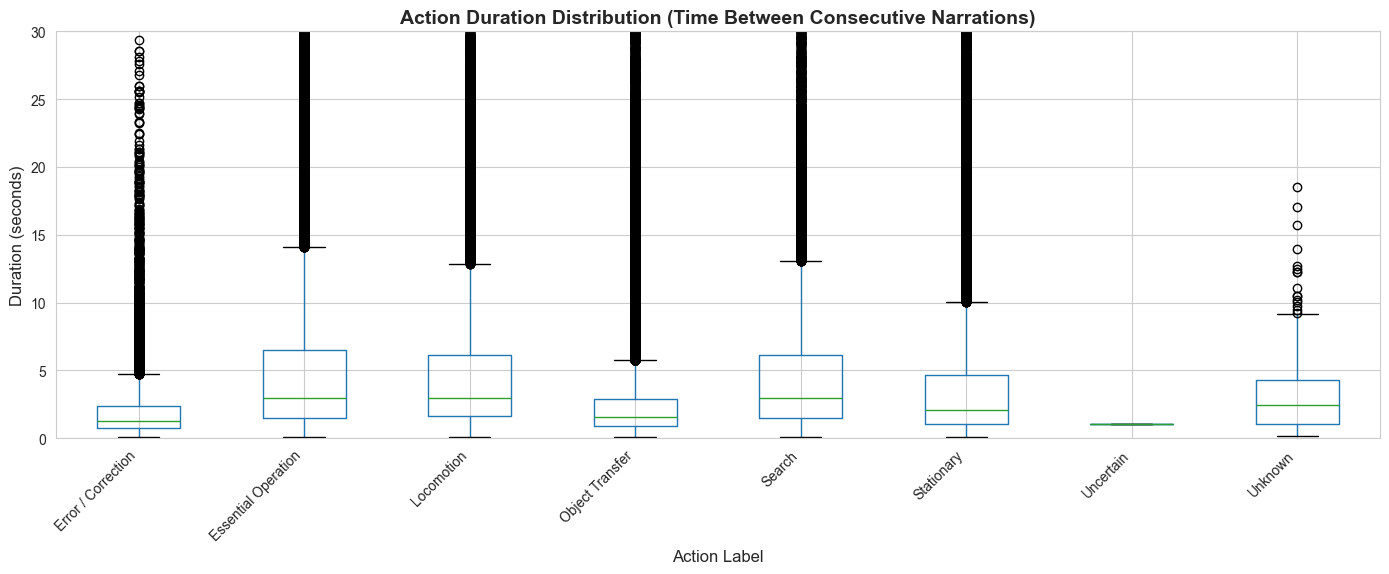


💡 Interpretation:
  - Locomotion: Typically quick bursts (walking/climbing)
  - Essential Operation: Longer durations (cutting, mixing, screwing)
  - Error: Usually brief (spill, drop, fumble)


In [15]:
# Calculate time gaps between consecutive narrations
df_sorted = df.sort_values(['video_uid', 'timestamp_sec'])
df_sorted['next_timestamp'] = df_sorted.groupby('video_uid')['timestamp_sec'].shift(-1)
df_sorted['duration'] = df_sorted['next_timestamp'] - df_sorted['timestamp_sec']

# Filter reasonable durations (0.1s to 60s)
df_duration = df_sorted[(df_sorted['duration'] > 0.1) & (df_sorted['duration'] < 60)]

# Stats by action
duration_stats = df_duration.groupby('action')['duration'].agg(['mean', 'median', 'std', 'count']).round(2)
duration_stats = duration_stats.sort_values('median', ascending=False)

print("⏱️  DURATION BETWEEN NARRATIONS (seconds)")
print("=" * 70)
print(duration_stats)
print("=" * 70)

# Visualize
fig, ax = plt.subplots(figsize=(14, 6))
df_duration.boxplot(column='duration', by='action', ax=ax)
ax.set_title('Action Duration Distribution (Time Between Consecutive Narrations)', fontsize=14, fontweight='bold')
ax.set_ylabel('Duration (seconds)', fontsize=12)
ax.set_xlabel('Action Label', fontsize=12)
ax.set_ylim(0, 30)  # Focus on 0-30s range
plt.xticks(rotation=45, ha='right')
plt.suptitle('')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("  - Locomotion: Typically quick bursts (walking/climbing)")
print("  - Essential Operation: Longer durations (cutting, mixing, screwing)")
print("  - Error: Usually brief (spill, drop, fumble)")

## 4. Filter by Action Type & Show Examples

Select an action type to see examples with narration text.

In [16]:
# Filter by action type (CHANGE THIS TO FOCUS ON DIFFERENT ACTIONS)
TARGET_ACTION = 'Locomotion'  # Options: 'Locomotion', 'Error / Correction', 'Search', etc.
N_EXAMPLES = 10

# Get examples with local IMU
df_action = df[df['action'] == TARGET_ACTION]
df_action_with_imu = df_action[df_action['video_uid'].isin(local_imu_uids)]

print(f"🎯 Action: {TARGET_ACTION}")
print(f"   Total in dataset: {len(df_action):,}")
print(f"   With local IMU: {len(df_action_with_imu):,}")

# Sample random examples
examples = df_action_with_imu.sample(min(N_EXAMPLES, len(df_action_with_imu)))

print(f"\n📋 Showing {len(examples)} examples with narration text:\n")
print("=" * 100)

for idx, row in examples.iterrows():
    print(f"Video: {row['video_uid'][:20]}... | Time: {row['timestamp_sec']:.1f}s | Scenario: {row['scenario']}")
    print(f"📝 Narration: {row['narration_text']}")
    print(f"🤔 Reasoning: {row['reasoning']}")
    print("-" * 100)

🎯 Action: Locomotion
   Total in dataset: 35,060
   With local IMU: 2,953

📋 Showing 10 examples with narration text:

Video: d9439e56-761c-428e-a... | Time: 159.3s | Scenario: Walking Outdoors
📝 Narration: #C C walks along the street
🤔 Reasoning: Body moving through space (walking), high body acceleration.
----------------------------------------------------------------------------------------------------
Video: da098288-2888-431a-8... | Time: 895.4s | Scenario: Walking Outdoors
📝 Narration: #C C walks on a footpath.
🤔 Reasoning: Body moving through space (walking) with high body acceleration.
----------------------------------------------------------------------------------------------------
Video: 7ea94f18-3b89-4c8e-a... | Time: 3362.3s | Scenario: Cooking
📝 Narration: #C C walks towards the refrigerator.
🤔 Reasoning: Body moving through space (walking towards the refrigerator), high body acceleration.
---------------------------------------------------------------------------------

## 5. Moment-Focused Visualization (±5s Windows)

Instead of showing entire videos, we zoom into **specific moments** around each label.

In [17]:
def visualize_moment(video_uid, timestamp, narration, action, reasoning, window_sec=5):
    """
    Visualize a specific moment: ±window_sec around the timestamp.
    Shows IMU pattern + narration text for validation.
    """
    imu = load_imu_data(video_uid)
    if imu is None:
        print(f"❌ No IMU for {video_uid}")
        return
    
    # Extract window
    t_start = max(0, timestamp - window_sec)
    t_end = timestamp + window_sec
    window = imu[(imu['timestamp'] >= t_start) & (imu['timestamp'] <= t_end)].copy()
    
    if len(window) == 0:
        print(f"❌ No IMU data in window for {video_uid}")
        return
    
    # Create figure
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Define colors
    colors = {
        'Locomotion': 'red',
        'Essential Operation': 'orange',
        'Object Transfer': 'gold',
        'Search': 'green',
        'Error / Correction': 'purple',
        'Stationary': 'gray'
    }
    action_color = colors.get(action, 'black')
    
    # Plot acceleration
    if 'accel_mag' in window.columns:
        axes[0].plot(window['timestamp'], window['accel_mag'], linewidth=1.5, color='blue', alpha=0.7)
        axes[0].axvline(timestamp, color=action_color, linewidth=3, alpha=0.8, linestyle='--', label='Label Time')
        axes[0].set_ylabel('Acceleration (m/s²)', fontsize=12, fontweight='bold')
        axes[0].set_title(f'IMU Moment: {action}', fontsize=14, fontweight='bold')
        axes[0].legend(loc='upper right')
        axes[0].grid(alpha=0.3)
    
    # Plot gyroscope
    if 'gyro_mag' in window.columns:
        axes[1].plot(window['timestamp'], window['gyro_mag'], linewidth=1.5, color='green', alpha=0.7)
        axes[1].axvline(timestamp, color=action_color, linewidth=3, alpha=0.8, linestyle='--')
        axes[1].set_ylabel('Gyroscope (rad/s)', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Time (seconds)', fontsize=12)
        axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Show narration info
    print("\n" + "=" * 80)
    print(f"🎬 Video: {video_uid}")
    print(f"⏰ Time: {timestamp:.2f}s (window: {t_start:.2f}s - {t_end:.2f}s)")
    print(f"🏷️  Action: {action}")
    print(f"📝 Narration: {narration}")
    print(f"🤔 Reasoning: {reasoning}")
    print("=" * 80)
    
    plt.show()
    
    # Show statistics for this window
    if 'accel_mag' in window.columns:
        accel_peak = window['accel_mag'].max()
        accel_mean = window['accel_mag'].mean()
        print(f"\n📊 Window stats: Peak accel = {accel_peak:.2f} m/s², Mean = {accel_mean:.2f} m/s²")
        
        # Validation hints
        if action == 'Locomotion' and accel_peak > 15:
            print("✅ High acceleration peak matches Locomotion expectation")
        elif action == 'Stationary' and accel_mean < 11:
            print("✅ Low acceleration matches Stationary expectation")
        elif action == 'Error / Correction' and accel_peak > 12:
            print("✅ Jerky motion (spike) matches Error/Correction")
    
    print("\n")

## 6. Visualize Examples for Selected Action

Shows **zoomed-in moments** for each example (not entire videos).


🎬 Video: d9439e56-761c-428e-a705-c362d61f8126
⏰ Time: 159.28s (window: 154.28s - 164.28s)
🏷️  Action: Locomotion
📝 Narration: #C C walks along the street
🤔 Reasoning: Body moving through space (walking), high body acceleration.


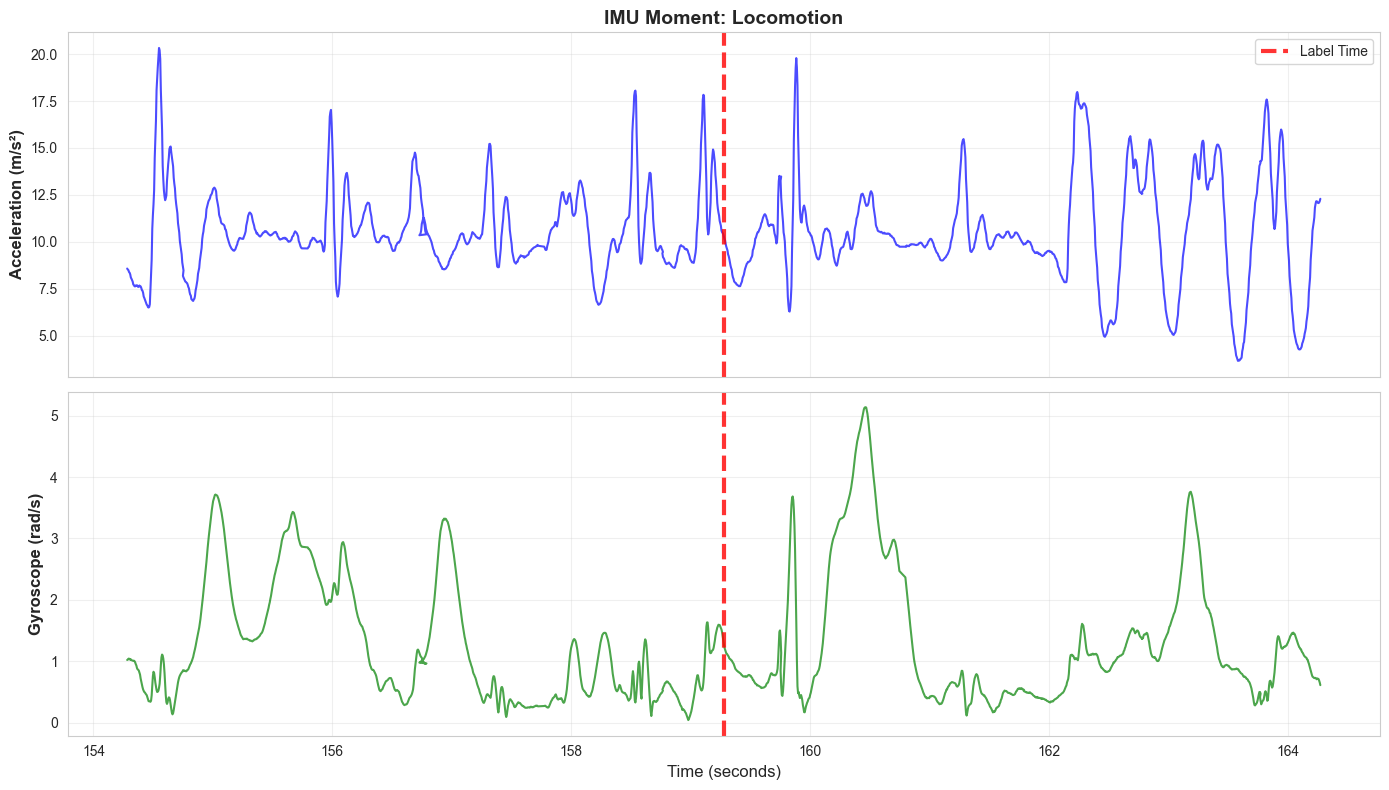


📊 Window stats: Peak accel = 20.32 m/s², Mean = 10.57 m/s²
✅ High acceleration peak matches Locomotion expectation



################################################################################


🎬 Video: da098288-2888-431a-8449-42ebcfc7252d
⏰ Time: 895.42s (window: 890.42s - 900.42s)
🏷️  Action: Locomotion
📝 Narration: #C C walks on a footpath.
🤔 Reasoning: Body moving through space (walking) with high body acceleration.


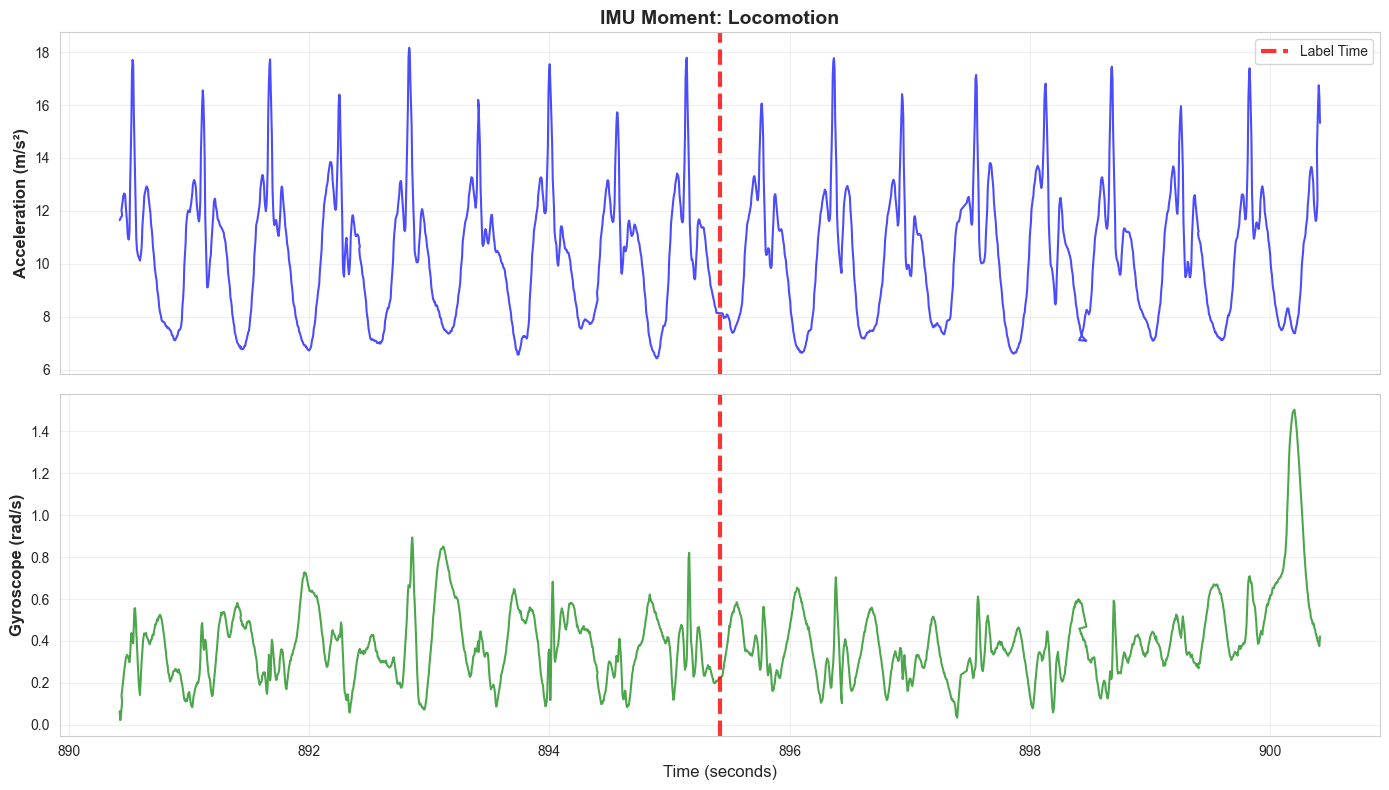


📊 Window stats: Peak accel = 18.16 m/s², Mean = 10.30 m/s²
✅ High acceleration peak matches Locomotion expectation



################################################################################


🎬 Video: 7ea94f18-3b89-4c8e-aa91-685a76fc4e01
⏰ Time: 3362.31s (window: 3357.31s - 3367.31s)
🏷️  Action: Locomotion
📝 Narration: #C C walks towards the refrigerator.
🤔 Reasoning: Body moving through space (walking towards the refrigerator), high body acceleration.


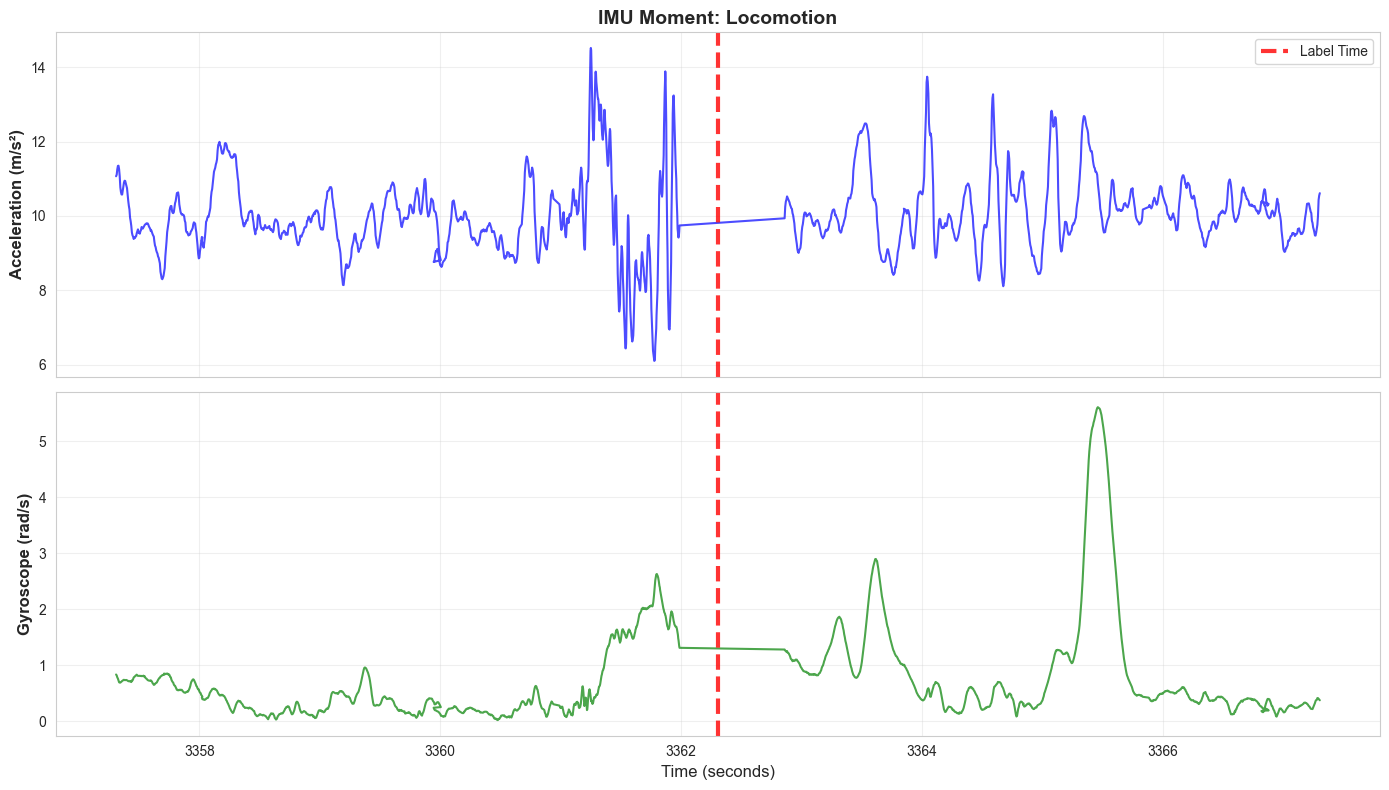


📊 Window stats: Peak accel = 14.52 m/s², Mean = 10.03 m/s²



################################################################################



In [18]:
# Show moment visualizations for the examples we sampled earlier
for idx, row in examples.head(3).iterrows():  # Show first 3 for brevity
    visualize_moment(
        video_uid=row['video_uid'],
        timestamp=row['timestamp_sec'],
        narration=row['narration_text'],
        action=row['action'],
        reasoning=row['reasoning'],
        window_sec=5  # ±5 second window
    )
    print("\n" + "#" * 80 + "\n")

## 7. Interactive: Inspect Specific Moment

Paste video UID + timestamp to zoom into any specific moment.

In [19]:
# Change these values to inspect any moment
INSPECT_UID = list(local_imu_uids)[0] if local_imu_uids else None
INSPECT_TIME = 100.0  # seconds

if INSPECT_UID:
    # Find closest label
    video_labels = df[df['video_uid'] == INSPECT_UID].sort_values('timestamp_sec')
    if len(video_labels) > 0:
        closest_label = video_labels.iloc[(video_labels['timestamp_sec'] - INSPECT_TIME).abs().argsort()[0]]
        
        visualize_moment(
            video_uid=closest_label['video_uid'],
            timestamp=closest_label['timestamp_sec'],
            narration=closest_label['narration_text'],
            action=closest_label['action'],
            reasoning=closest_label['reasoning'],
            window_sec=10  # Larger window for exploration
        )
else:
    print("No local IMU files available. Download some first!")

KeyError: 0

## 8. Action-Specific Analysis Summary

In [ ]:
print("=" * 80)
print("ACTION TYPE CHARACTERISTICS")
print("=" * 80)
print("\n🚶 Locomotion:")
print("   Expected: High accel peaks (>15 m/s²), brief duration")
print("   Narrations: 'walks', 'climbs', 'stands up'")

print("\n🔧 Essential Operation:")
print("   Expected: Moderate accel, sustained, variable gyro")
print("   Narrations: 'cuts', 'washes', 'mixes', 'screws'")

print("\n📦 Object Transfer:")
print("   Expected: Brief accel spikes, low-moderate intensity")
print("   Narrations: 'picks up', 'puts down', 'takes', 'places'")

print("\n👀 Search:")
print("   Expected: High gyro (head movement), low accel")
print("   Narrations: 'looks for', 'checks', 'inspects'")

print("\n⚠️  Error / Correction:")
print("   Expected: Irregular spikes, jerky patterns")
print("   Narrations: 'spills', 'drops', 'fumbles', 'adjusts'")

print("\n🧘 Stationary:")
print("   Expected: Low accel (<11 m/s²), minimal gyro")
print("   Narrations: 'waits', 'talks', 'sits'")
print("=" * 80)

## 9. Next Steps

```bash
# Download all IMU data
cd Ego4d
python -m ego4d.cli.cli \
    --output_directory ../data/ego4d_data \
    --datasets imu \
    --video_uids ../target_uids.csv

# Then re-run this notebook to validate more examples!
```